In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione grafici
sns.set_theme(style="whitegrid")
%matplotlib inline

In [24]:
# Caricamento dati da CSV (estratti dal DWH)
df = pd.read_csv("esercizio_bikesharing_sintetico.csv")

# Parsing data
df['data_completa'] = pd.to_datetime(df['data_completa'])

df.head()


,data_completa,mese,giorno_settimana,is_weekend,temp_c,pioggia_mm,evento,total_rentals,settimana_anno
0,2025-01-01,1,2,0,8.0,0.0,0,122,1
1,2025-01-02,1,3,0,4.7,0.0,0,94,1
2,2025-01-03,1,4,0,9.2,0.0,0,104,1
3,2025-01-04,1,5,1,9.7,0.0,0,116,1
4,2025-01-05,1,6,1,2.5,0.0,0,131,1


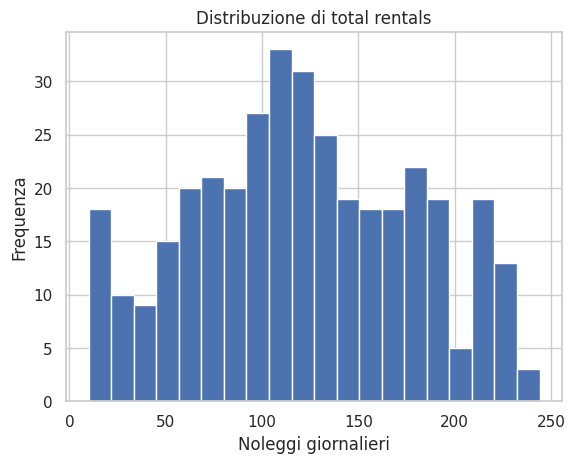

In [44]:
plt.hist(df["total_rentals"], bins=20)
plt.xlabel("Noleggi giornalieri")
plt.ylabel("Frequenza")
plt.title("Distribuzione di total rentals")
plt.show()

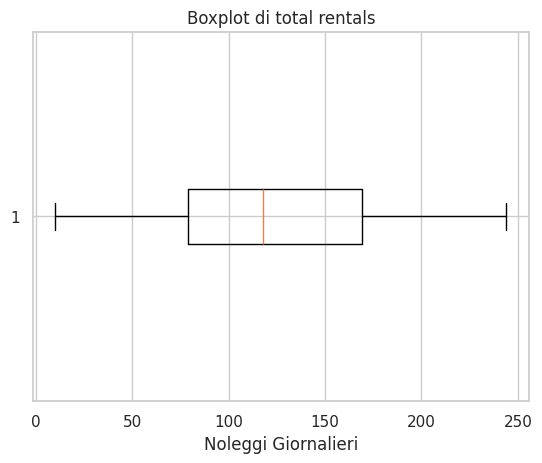

In [45]:
plt.boxplot(df["total_rentals"], vert=False)
plt.xlabel("Noleggi Giornalieri")
plt.title("Boxplot di total rentals")
plt.show()

In [46]:
# Selezioniamo le feature
features = ['mese', 'giorno_settimana', 'is_weekend']
target = 'total_rentals'

X = df[features]
y = df[target]

# verifichiamo la dimensione di X ed Y
print(f"Shape di X: {X.shape}")
print(f"Shape di y: {y.shape}")

Shape di X: (365, 3)
Shape di y: (365,)


In [47]:
from sklearn.model_selection import train_test_split

# Dividiamo: 80% Training, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 292
Test samples: 73


In [49]:
# 1. Importiamo la classe che utilizzeremo
from sklearn.linear_model import LinearRegression

# 1. Istanziazione
model = LinearRegression()

# 2. Fitting (Apprendimento)
model.fit(X_train, y_train)

# Vediamo cosa ha imparato (i coefficienti)
print("Intercetta:", model.intercept_)
print("Coefficienti:", dict(zip(features, model.coef_)))

Intercetta: 105.64777504721842
Coefficienti: {'mese': np.float64(1.6511279423582068), 'giorno_settimana': np.float64(4.424714493751813), 'is_weekend': np.float64(-14.78365361230038)}


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generiamo previsioni
y_pred = model.predict(X_test)

# Calcoliamo l'errore
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE (Errore Medio Assoluto): {mae:.2f}")
print(f"RMSE (Radice Errore Quadratico Medio): {rmse:.2f}")

MAE (Errore Medio Assoluto): 52.60
RMSE (Radice Errore Quadratico Medio): 65.52


In [51]:
df['total_rentals'].describe()

count    365.000000
mean     121.652055
std       57.801403
min       10.000000
25%       79.000000
50%      118.000000
75%      169.000000
max      244.000000
Name: total_rentals, dtype: float64

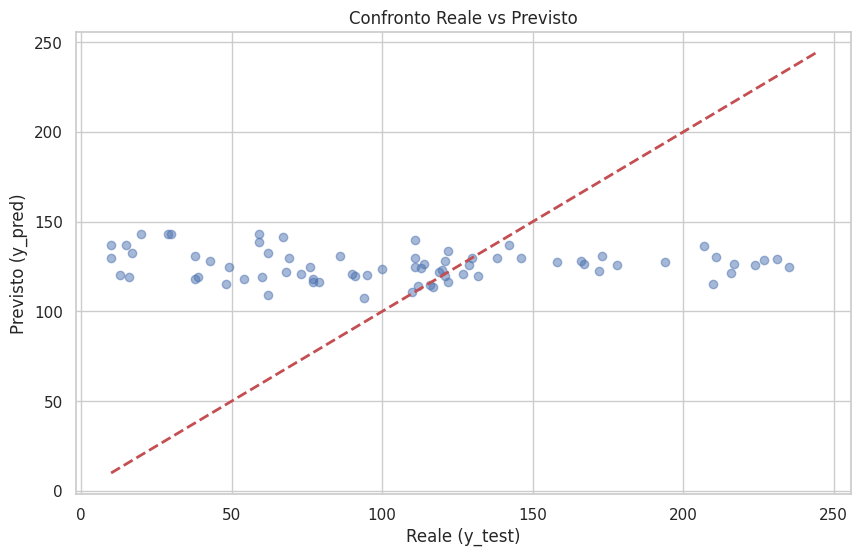

In [52]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Linea ideale
plt.xlabel('Reale (y_test)')
plt.ylabel('Previsto (y_pred)')
plt.title('Confronto Reale vs Previsto')
plt.show()